# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
- Preprocess
    - StandardScaler
    - PCA
- Models
    - Kmeans
    - DBSCAN
    - AglomerativeClustering
- Conclusions i resultats

**Funcions a definir:**
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per silouette i inercia





# Llibreries i configuracio

In [35]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Evitar warning
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme()

# Carrega dels datasets

In [26]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'


df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [76]:
def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X


def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(8,4))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol} | n_components = {n_components}")
    plt.legend()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()


def evaluacio_cluster(clusterer: KMeans, X: np.array, labels: np.array, nom_model: str, tipo_dades: str):
    resultats = {
        "model": nom_model,
        "tipo_dades": tipo_dades,
        "n_clusters" : len(set(labels))
    }

    resultats["silhouette"] = silhouette_score(X, labels)
    resultats["inercia"] = clusterer.inertia_
    
    return resultats

def plot_seleccio_kmeans(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    fig = plt.figure(figsize=(20, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    sns.lineplot(results, y = "inercia", x = "n_clusters", hue = "tipo_dades", ax=ax1, style="tipo_dades", markers=['o', 'D'])
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", ax= ax2, style="tipo_dades", markers = ['o', 'D'])
    plt.suptitle(f"Selecció de k ({nom_dades})")
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

# Preprocessament
- Separar variables de codi_barri
- Escalar els conjunts de dades
- Aplicar PCA
- Aplicar clustering amb pca i amb escalat
- Seleccionar nombre de clusters
- Interpretació dels clústers

In [28]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [29]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15)
X_23_scaled = scaler.fit_transform(X_23)
X_deltes_scaled = scaler.fit_transform(X_deltes)

# Dades 2015

## PCA (Principal Component analysis)

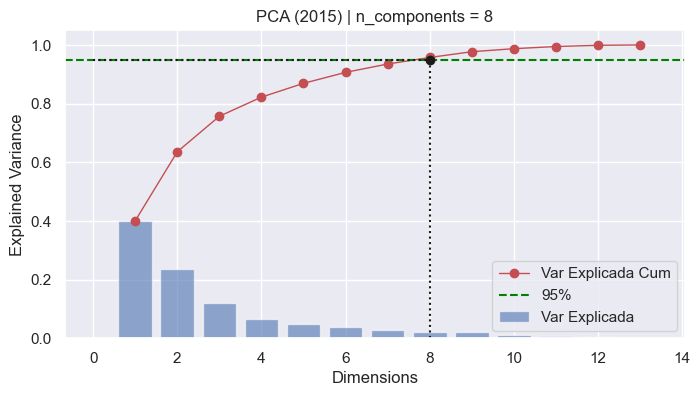

In [30]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- Es pot observar que es necessiten els 8 principal components per explicar el 95% de la variança. 5 per explicar el 90%.

In [31]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_15 = 8

pca_15_fixed = PCA(n_components= n_components_15, random_state= 42)
X_pca_15_fixed = pca_15_fixed.fit_transform(X_15_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_15_fixed, columns=[f'PC{i}' for i in range(1, n_components_15 + 1)], index=df_2015['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.355191,4.490169,1.126331,-1.615403,1.318966,-0.282564,-0.993202,1.305772
2,5.910670,6.495680,-1.196214,-0.596422,0.320486,-0.553012,2.466511,-0.847702
3,3.092488,3.295516,-1.190071,-1.250329,-0.697302,-0.473648,0.586394,0.859204
4,4.648373,4.508592,-0.723265,-0.894906,-0.287535,-0.869041,0.112567,0.222926
5,1.805701,0.316673,0.881500,0.497075,-0.832472,0.520835,-0.554909,-0.072050


In [49]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2015 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_15_scaled)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_scaled, X_15_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_15_fixed)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_pca, X_pca_15_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2015_df = pd.DataFrame(resultats_clusters_2015)
resultats_2015_df

c:\Users\USER\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.292254,659.826884
1,KMeans_2,pca,2,0.306500,619.181894
2,KMeans_3,escalades,3,0.311000,525.130666
3,KMeans_3,pca,3,0.327722,485.412025
4,KMeans_4,escalades,4,0.286169,449.629904
5,KMeans_4,pca,4,0.306513,410.189102
6,KMeans_5,escalades,5,0.308905,375.862366
7,KMeans_5,pca,5,0.331401,336.758874
8,KMeans_6,escalades,6,0.264832,325.669483
9,KMeans_6,pca,6,0.272640,286.741665


**Observacions:**
- Es pot observar a la taula que els valors den pca obtenen resultats lleugerament superiors en silhouette i inercia.
- Destaquen els models amb 3 i 5 clusters. 
Es veu millor de manera gràfica.

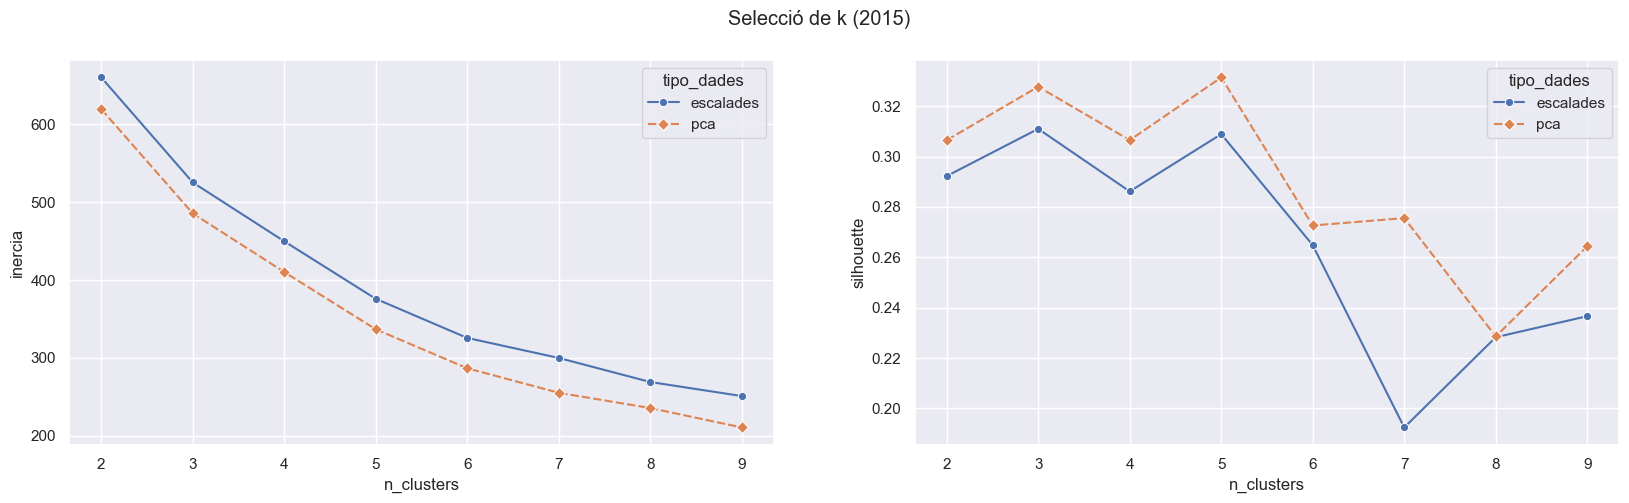

In [75]:
plot_seleccio_kmeans(resultats_2015_df, "2015", "seleccio_k_2015.png")

**Observacions:**
- Tal i com es menciona anteriorment, el nombre de clusters òptim són 3 o 5 clusters, en ambdós casos s' obté un bon valor de silhouette, i es pot considerar el colze en el gràfic de la inèrcia. 
- Un fet clar, és que les dades amb pca aplicada, obtenen lleugerament millors resultats.

# Dades 2023

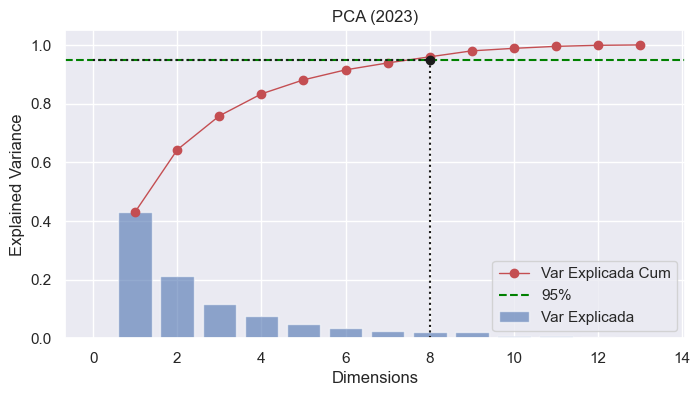

In [90]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

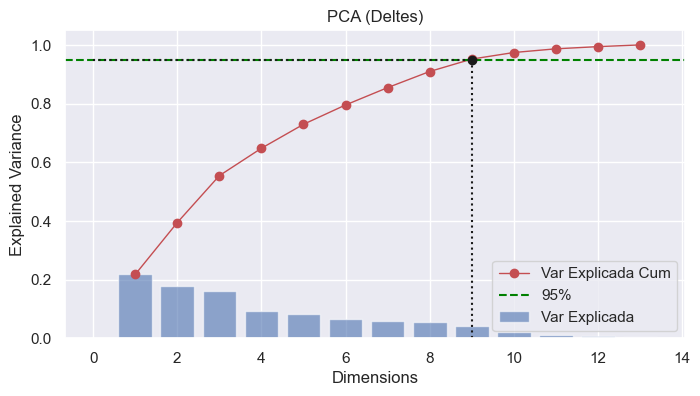

In [91]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components